<a href="https://colab.research.google.com/github/rmani10063/metadrive-insight/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import os

print(os.listdir('/content/drive/MyDrive'))

['battery', 'Colab Notebooks', 'repair and mainteance of refrigerators (1).docx', 'Package.ssf', 'New Microsoft Office Word Document.docx', 'New Microsoft Office Excel Worksheet.xlsx', 'New Microsoft Office Word Document (2).docx', 'New Microsoft Office Excel Worksheet (2).xlsx', 'Contacts-2020-07-01(1).vcf', 'MRAGR _VZM Section-A', 'POD Request File.xlsx', 'scholor3.prn', 'Capture.PNG', 'VIDEO', 'om', 'IMAGES', 'PICTURES ALL IN ONE', 'INTERNAL2 0PHONE', 'RUDRAPANKTI MANIKANTHA', 'INTERNAL', 'CONTACTS', 'MUSIC', 'RECYCALE PHOTES', 'R&AC. ASSIGNMENT-1@2.pdf', 'MY PIC (1).jpg', 'RUDRAPANKTI MANIKANTHA.pdf', 'house_price_proj.gdoc', 'MY PIC.jpg', 'Untitled form (File responses)', 'PATENT.jpg', 'Contact Information.gform', 'MITS ID CARD.pdf', 'ID JPG.jpg', 'R.MANIKNTHA RESUME.pdf', 'Untitled document.gdoc', 'Resume', 'R (1).MANIKANTHA.pdf', 'R.MANIKANTHA.pdf', 'Contact Information (Responses).gsheet', 'asai university', 'project', 'SANITIZING MACHINE', 'MY PERSONAL DOCUMENTS', "CERFICATES'

In [32]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "DEFECT_DATASET" in dirs:
        print("FOUND PATH:", os.path.join(root, "DEFECT_DATASET"))

FOUND PATH: /content/drive/MyDrive/battery/CNN_BATTERY/DEFECT_DATASET


In [34]:
data_path = "/content/drive/MyDrive/battery/CNN_BATTERY/DEFECT_DATASET"

In [35]:
print(os.listdir(data_path))

['CRACK', 'GOOD', 'PINHOLE']


In [48]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [50]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [51]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.8350 - loss: 0.4508 - val_accuracy: 0.9267 - val_loss: 0.1965
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 36s 296ms/step - accuracy: 0.9150 - loss: 0.2241 - val_accuracy: 0.9800 - val_loss: 0.1002
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 40s 335ms/step - accuracy: 0.9517 - loss: 0.1460 - val_accuracy: 0.9933 - val_loss: 0.0465
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 35s 291ms/step - accuracy: 0.9567 - loss: 0.1124 - val_accuracy: 0.8800 - val_loss: 0.3233
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 34s 284ms/step - accuracy: 0.9650 - loss: 0.0884 - val_accuracy: 0.9867 - val_loss: 0.0334
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 37s 306ms/step - accuracy: 0.9717 - loss: 0.0703 - val_accuracy: 0.9733 - val_loss: 0.0548
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 35s 290ms/step - accuracy: 0.9783 - loss: 0.0498 - val_accuracy: 0.9933 - val_loss: 0.0594
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 34s 286ms/step - accuracy: 0.9900 - loss: 0.0

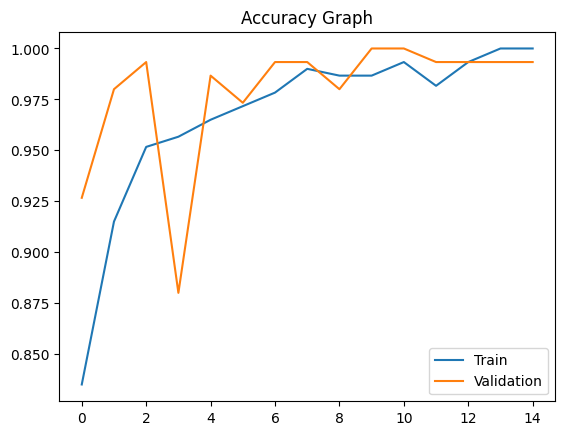

In [54]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [55]:
model.save("/content/drive/MyDrive/CNN_BATTERY/defect_model.h5")
print("✅ Model Saved")

✅ Model Saved


In [65]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Saving 18.png to 18.png


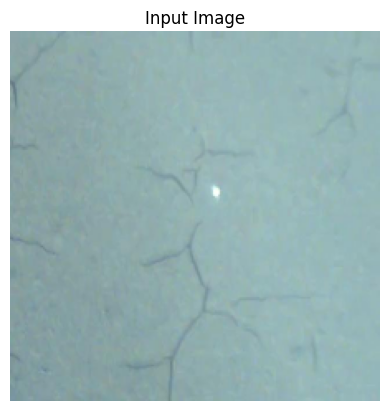

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

file_bytes = np.asarray(bytearray(uploaded[img_path]), dtype=np.uint8)
img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis("off")
plt.show()

In [67]:
img_resized = cv2.resize(img, (224,224)) / 255.0
img_input = np.expand_dims(img_resized, axis=0)

pred = model.predict(img_input)

class_names = list(train_data.class_indices.keys())

label = class_names[np.argmax(pred)]
confidence = np.max(pred)

print("Prediction:", label)
print("Confidence:", confidence*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Prediction: PINHOLE
Confidence: 99.99898


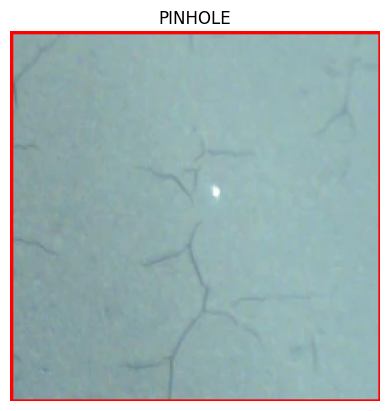

In [68]:
original = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 180,255,cv2.THRESH_BINARY_INV)

contours,_ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    if cv2.contourArea(cnt) < 100:
        continue
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(original,(x,y),(x+w,y+h),(0,0,255),2)

plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title(label)
plt.axis("off")
plt.show()